In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
GPU available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [38]:
from torchvision import transforms

train_transforms = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.RandomRotation(15),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomResizedCrop(224, scale=(0.9,1.0)),
    
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


test_transforms = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [39]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="../dataset/Training",
    transform=train_transforms
)

test_dataset = ImageFolder(
    root="../dataset/Testing",
    transform=test_transforms
)

In [40]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.3850982].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.1062311].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.169412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].


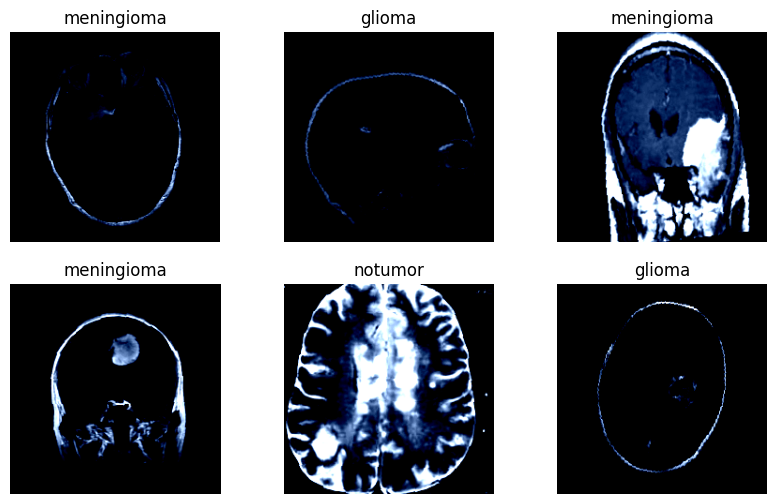

In [41]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

In [42]:
import torch.nn as nn
import torch.optim as optim

In [43]:
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super(BrainTumorCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BrainTumorCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Using device:", device)

Using device: cuda


In [45]:
from tqdm import tqdm

In [ ]:
num_epochs = 20

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validation step
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}  Validation Accuracy: {accuracy:.2f}%")

Epoch 1/20:  91%|█████████ | 159/175 [00:35<00:03,  4.42it/s]

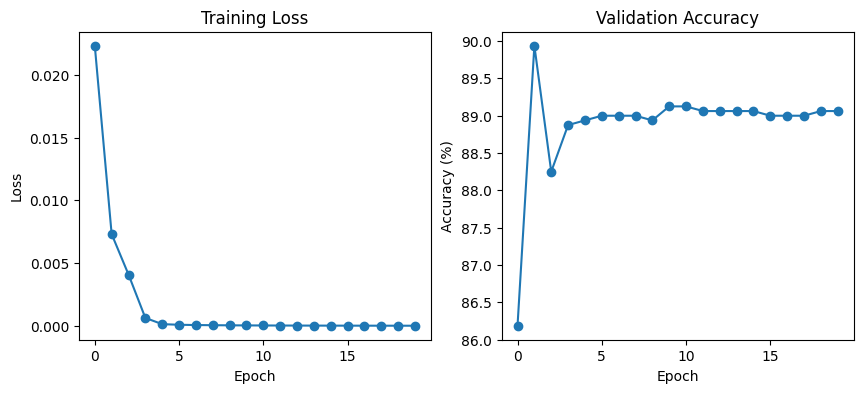

In [32]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(val_accuracies, marker="o")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()